# EDA on Real Reliability Data
This notebook loads the real dataset, summarizes quality, and visualizes distributions and state mapping.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys


sys.path.append(str(Path().resolve().parent))

from src.pipeline.data_loader import load_real_dataset
from src.pipeline.preprocessing import preprocess_real_dataframe
from src.pipeline.state_mapping import add_state_columns
from src.pipeline.transition_estimation import estimate_transition_matrix

plt.style.use('default')


In [2]:
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
df_raw = load_real_dataset(project_root=project_root, dataset_path=project_root / 'data' / 'real')
df = add_state_columns(preprocess_real_dataframe(df_raw))
df.shape


/Users/ayoub/work/MS-DS_ML_Projects/ml_probabilistic/src/pipeline/preprocessing.py:90: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["temperature"] = df[temp_col].astype(float)
/Users/ayoub/work/MS-DS_ML_Projects/ml_probabilistic/src/pipeline/preprocessing.py:91: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["power_usage"] = df[power_col].astype(float)
/Users/ayoub/work/MS-DS_ML_Projects/ml_probabilistic/src/pipeline/preprocessing.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of cal

(86650, 15)

In [3]:
df.head()


,timestamp,time_hours,time_delta_hours,temperature,ecc_count,xid_code,utilization,power_usage,retired_pages,stress_score,gpu0_core_temp_avg,total_power_avg,value,state,state_idx
0,2020-03-09 12:00:00+00:00,0.00,0.00,34.000000,0,0,60.606061,420.0,0.0,0.481818,34.000000,420.0,0,Degraded,1
1,2020-03-09 12:15:00+00:00,0.25,0.25,34.000000,0,0,60.606061,420.0,0.0,0.481818,34.000000,420.0,0,Degraded,1
2,2020-03-09 12:30:00+00:00,0.50,0.25,34.000000,0,0,60.606061,420.0,0.0,0.481818,34.000000,420.0,0,Degraded,1
3,2020-03-09 12:45:00+00:00,0.75,0.25,34.057143,0,0,60.606061,420.0,0.0,0.487532,34.057143,420.0,0,Degraded,1
4,2020-03-09 13:00:00+00:00,1.00,0.25,34.044444,0,0,60.606061,420.0,0.0,0.486263,34.044444,420.0,0,Degraded,1


In [4]:
df.describe(include='all').transpose().head(30)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,86650,NaN,NaN,NaN,2021-07-02 20:32:41.470282+00:00,2020-03-09 12:00:00+00:00,2020-11-18 13:33:45+00:00,2021-07-04 14:52:30+00:00,2022-02-15 06:26:15+00:00,2022-09-28 22:00:00+00:00,NaN
time_hours,86650.0,NaN,NaN,NaN,11528.544853,0.0,6097.5625,11570.875,16986.4375,22402.0,6311.084656
time_delta_hours,86650.0,NaN,NaN,NaN,0.258534,0.0,0.25,0.25,0.25,673.0,2.293912
temperature,86650.0,NaN,NaN,NaN,35.39592,26.444444,34.911111,35.0,36.955556,82.043478,3.169639
ecc_count,86650.0,NaN,NaN,NaN,0.111252,0.0,0.0,0.0,0.0,3.0,0.551636
xid_code,86650.0,NaN,NaN,NaN,1.771495,0.0,0.0,0.0,0.0,48.0,8.797375
utilization,86650.0,NaN,NaN,NaN,55.496347,0.0,51.515152,60.606061,60.606061,100.0,19.606872
power_usage,86650.0,NaN,NaN,NaN,428.671359,379.555556,418.666667,420.0,420.0,1772.173913,85.596698
retired_pages,86650.0,NaN,NaN,NaN,0.055626,0.0,0.0,0.0,0.0,1.5,0.275818
stress_score,86650.0,NaN,NaN,NaN,0.589286,0.0,0.5,0.581818,0.781818,1.0,0.211401


In [5]:
df.isna().mean().sort_values(ascending=False).head(20)


timestamp             0.0
time_hours            0.0
time_delta_hours      0.0
temperature           0.0
ecc_count             0.0
xid_code              0.0
utilization           0.0
power_usage           0.0
retired_pages         0.0
stress_score          0.0
gpu0_core_temp_avg    0.0
total_power_avg       0.0
value                 0.0
state                 0.0
state_idx             0.0
dtype: float64

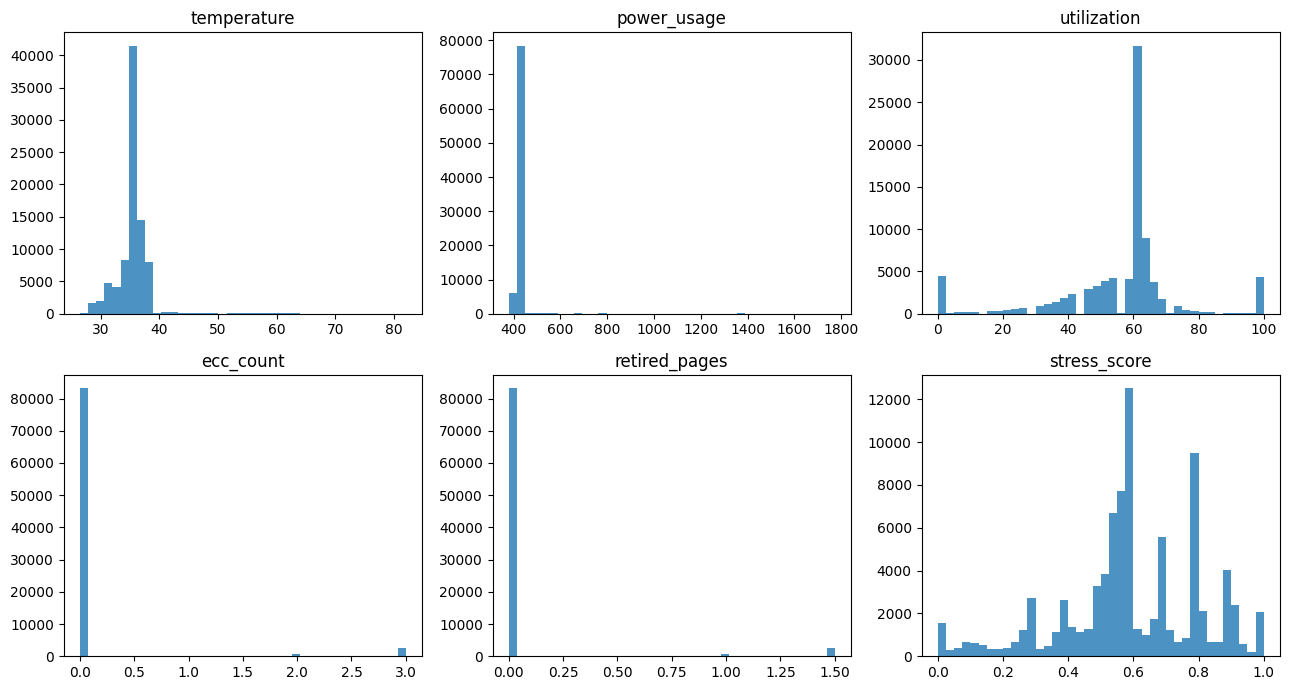

In [6]:
num_cols = ['temperature', 'power_usage', 'utilization', 'ecc_count', 'retired_pages', 'stress_score']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), num_cols):
    ax.hist(df[c].dropna(), bins=40, alpha=0.8)
    ax.set_title(c)
plt.tight_layout()


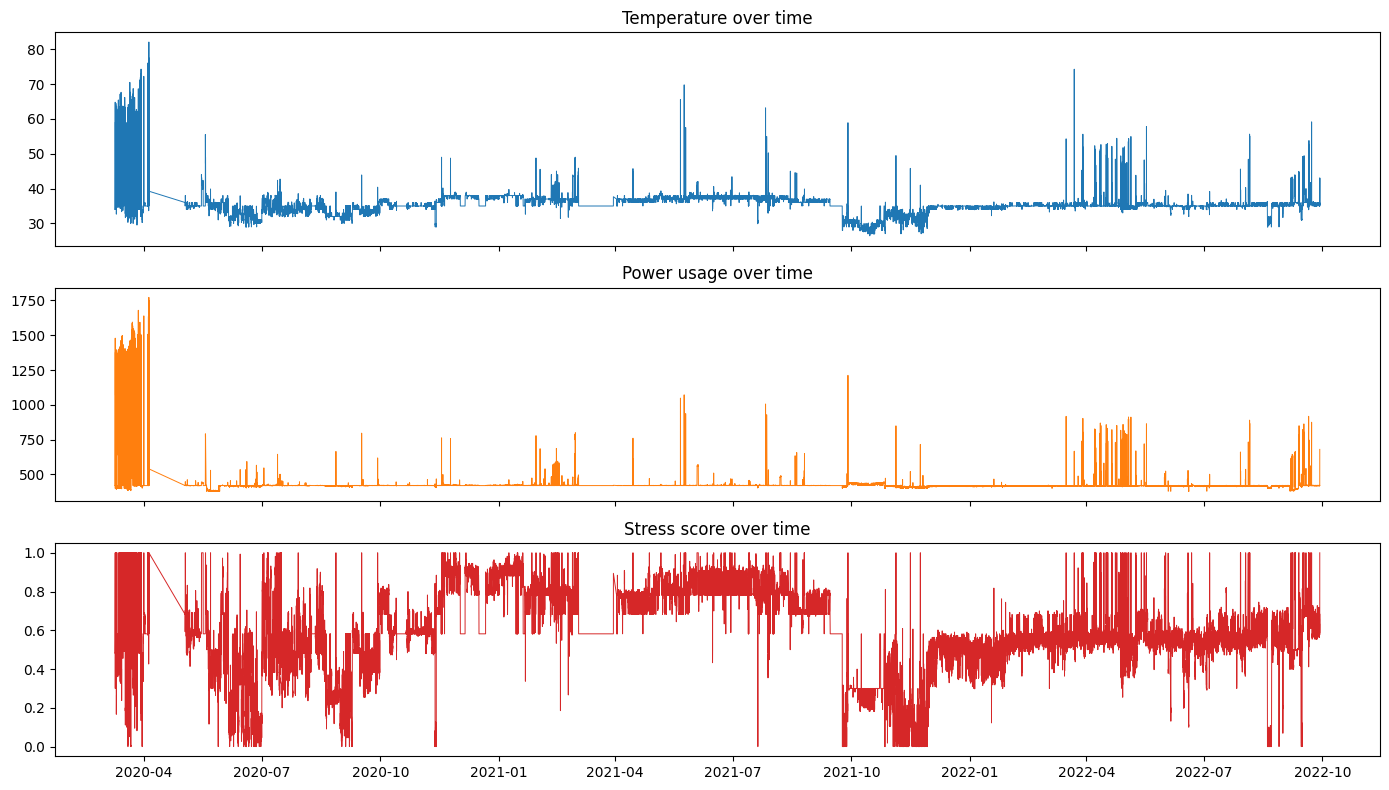

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df['timestamp'], df['temperature'], lw=0.7)
axes[0].set_title('Temperature over time')
axes[1].plot(df['timestamp'], df['power_usage'], lw=0.7, color='tab:orange')
axes[1].set_title('Power usage over time')
axes[2].plot(df['timestamp'], df['stress_score'], lw=0.7, color='tab:red')
axes[2].set_title('Stress score over time')
plt.tight_layout()


In [8]:
state_counts = df['state'].value_counts()
state_counts


state
MaintenanceRequired    40243
Degraded               15659
FailedRecoverable      15067
FailedPermanent         9912
Healthy                 5769
Name: count, dtype: int64

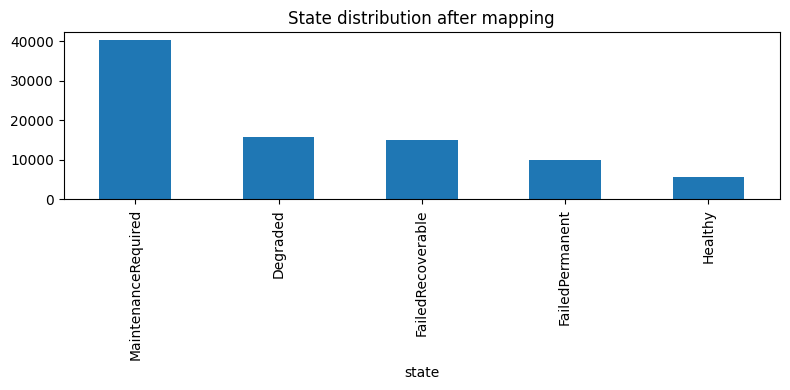

In [9]:
state_counts.plot(kind='bar', figsize=(8,4), title='State distribution after mapping')
plt.tight_layout()


In [10]:
P = estimate_transition_matrix(df)
p_df = pd.DataFrame(P, index=['Healthy','Degraded','MaintenanceRequired','FailedRecoverable','FailedPermanent'], columns=['Healthy','Degraded','MaintenanceRequired','FailedRecoverable','FailedPermanent'])
p_df


,Healthy,Degraded,MaintenanceRequired,FailedRecoverable,FailedPermanent
Healthy,0.897556,0.094817,0.006414,0.000173,0.001040
Degraded,0.034740,0.867169,0.093940,0.001149,0.003001
MaintenanceRequired,0.000944,0.036329,0.934051,0.024402,0.004274
FailedRecoverable,0.000066,0.001460,0.064711,0.893940,0.039822
FailedPermanent,0.000807,0.004843,0.017254,0.060236,0.916860


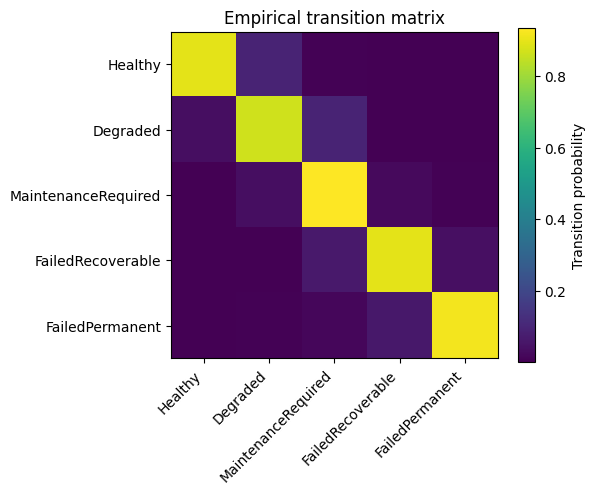

In [11]:
plt.figure(figsize=(6,5))
plt.imshow(P, cmap='viridis')
plt.colorbar(label='Transition probability')
plt.xticks(range(5), p_df.columns, rotation=45, ha='right')
plt.yticks(range(5), p_df.index)
plt.title('Empirical transition matrix')
plt.tight_layout()


In [12]:
from pathlib import Path

out_dir = Path('../results/report_figures') if Path.cwd().name == 'notebooks' else Path('results/report_figures')
out_dir.mkdir(parents=True, exist_ok=True)

# Save current transition matrix heatmap
plt.figure(figsize=(6,5))
plt.imshow(P, cmap='viridis')
plt.colorbar(label='Transition probability')
plt.xticks(range(5), p_df.columns, rotation=45, ha='right')
plt.yticks(range(5), p_df.index)
plt.title('Empirical transition matrix')
plt.tight_layout()
plt.savefig(out_dir / 'eda_transition_matrix.png', dpi=150)
plt.close()

# Save state distribution
state_counts.plot(kind='bar', figsize=(8,4), title='State distribution after mapping')
plt.tight_layout()
plt.savefig(out_dir / 'eda_state_distribution.png', dpi=150)
plt.close()

# Save tables
p_df.to_csv(out_dir / 'eda_transition_matrix.csv')
df.describe().to_csv(out_dir / 'eda_summary_stats.csv')

print('Saved report artifacts to', out_dir.resolve())

Saved report artifacts to /Users/ayoub/work/MS-DS_ML_Projects/ml_probabilistic/results/report_figures
